In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
db = pd.read_csv('datasets/diabetic_data.csv')
db.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
db.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [8]:
db.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [10]:
db['max_glu_serum'] = db['max_glu_serum'].replace('None', np.nan).fillna('None')

In [11]:
db['A1Cresult'] = db['A1Cresult'].replace('None', np.nan).fillna('None')

In [12]:
db.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

#Visualize the distribution of categorical features - race and gender.

In [15]:
db['race'] = db['race'].replace('?','Unknown')

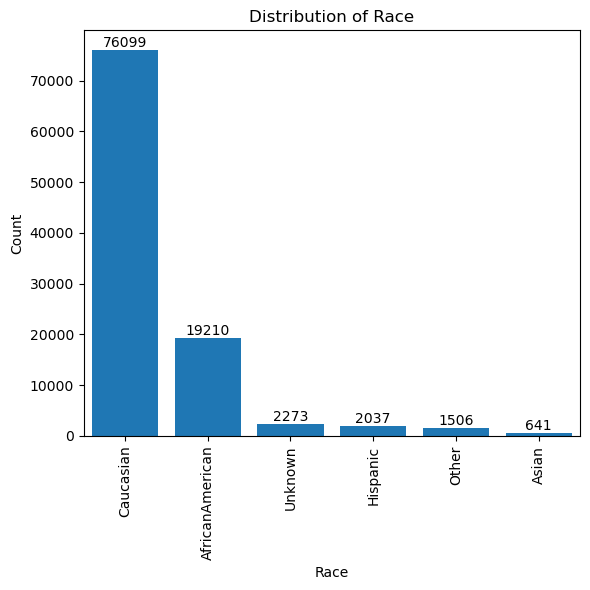

In [24]:
plt.figure(figsize=(6,6))
db['race'].value_counts().plot(kind='bar')
plt.xlabel("Race")
plt.ylabel("Count")
plt.title("Distribution of Race")
race_counts = db['race'].value_counts()
bars = plt.bar(race_counts.index, race_counts.values)
plt.bar_label(bars)   

plt.tight_layout()
plt.show()

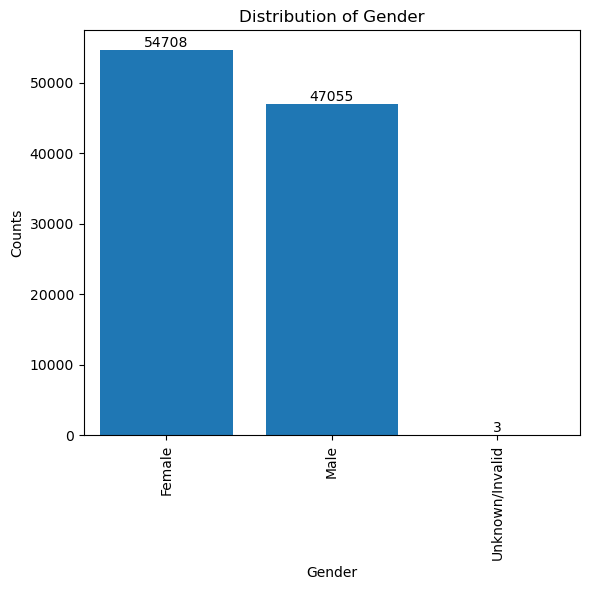

In [27]:
plt.figure(figsize=(6,6))
db['gender'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Counts")
plt.title("Distribution of Gender")
gender_counts = db['gender'].value_counts()
bars = plt.bar(gender_counts.index, gender_counts.values)
plt.bar_label(bars)
plt.tight_layout()
plt.show()

#Explore the relationship between readmission status and age

In [28]:
pd.crosstab(db['age'], db['readmitted'])

readmitted,<30,>30,NO
age,,,
[0-10),3,26,132
[10-20),40,224,427
[20-30),236,510,911
[30-40),424,1187,2164
[40-50),1027,3278,5380
[50-60),1668,5917,9671
[60-70),2502,7897,12084
[70-80),3069,9475,13524
[80-90),2078,6223,8896


In [30]:
readmit_age = db.groupby('age')['readmitted'].apply(
    lambda x: (x !='NO').mean() * 100)
print(readmit_age)

age
[0-10)      18.012422
[10-20)     38.205499
[20-30)     45.021123
[30-40)     42.675497
[40-50)     44.450181
[50-60)     43.955726
[60-70)     46.252724
[70-80)     48.120301
[80-90)     48.270047
[90-100)    40.028643
Name: readmitted, dtype: float64


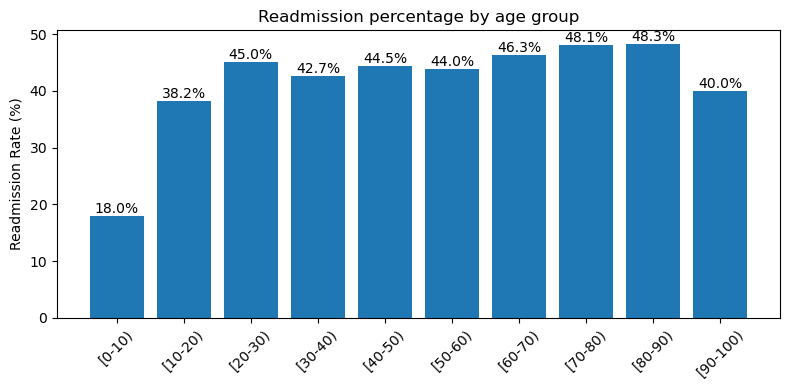

In [35]:
plt.figure(figsize=(8,4))

bars = plt.bar(readmit_age.index, readmit_age.values)

plt.bar_label(bars, fmt='%.1f%%')
plt.xticks(rotation =45)
plt.ylabel("Readmission Rate (%)")
plt.title("Readmission percentage by age group")

plt.tight_layout()
plt.show()

#Investigate correlations between numerical features

In [36]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [38]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures","num_medications", "number_outpatient",
                "number_emergency","number_inpatient","number_diagnoses"]

In [39]:
num_db = db[numeric_cols]

In [40]:
corr = num_db.corr()
print(corr)

                    time_in_hospital  num_lab_procedures  num_procedures  \
time_in_hospital            1.000000            0.318450        0.191472   
num_lab_procedures          0.318450            1.000000        0.058066   
num_procedures              0.191472            0.058066        1.000000   
num_medications             0.466135            0.268161        0.385767   
number_outpatient          -0.008916           -0.007602       -0.024819   
number_emergency           -0.009681           -0.002279       -0.038179   
number_inpatient            0.073623            0.039231       -0.066236   
number_diagnoses            0.220186            0.152773        0.073734   

                    num_medications  number_outpatient  number_emergency  \
time_in_hospital           0.466135          -0.008916         -0.009681   
num_lab_procedures         0.268161          -0.007602         -0.002279   
num_procedures             0.385767          -0.024819         -0.038179   
num_medicat

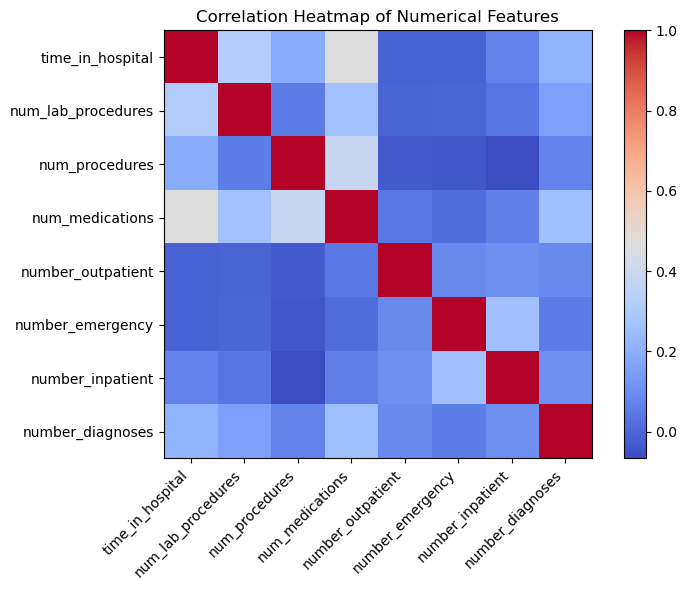

In [46]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#Analyze the distribution of medication changes and total medications taken

In [47]:
db['change'].value_counts()

change
No    54755
Ch    47011
Name: count, dtype: int64

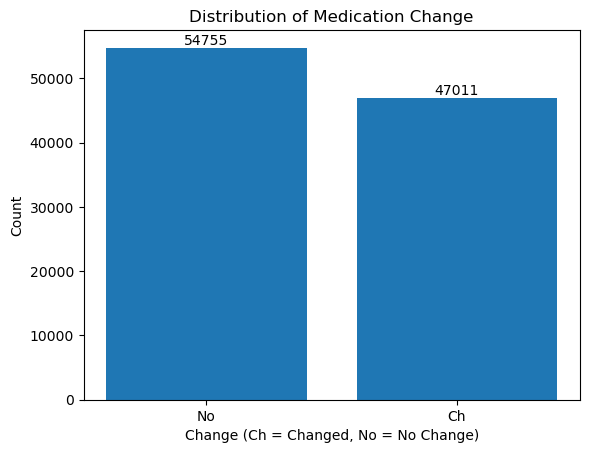

In [49]:
change_counts = db['change'].value_counts()
bars = plt.bar(change_counts.index, change_counts.values)
plt.bar_label(bars)

plt.title("Distribution of Medication Change")
plt.xlabel("Change (Ch = Changed, No = No Change)")
plt.ylabel("Count")
plt.show()

In [50]:
db['num_medications'].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

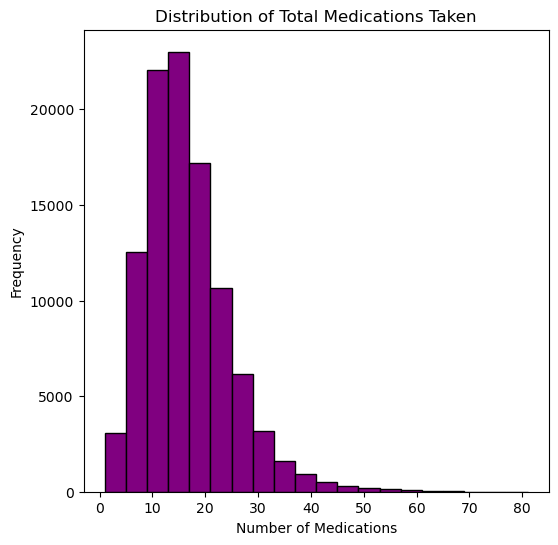

In [53]:
plt.figure(figsize=(6,6))
plt.hist(db['num_medications'], bins= 20, color='purple',edgecolor='black')
plt.xlabel('Number of Medications')
plt.ylabel('Frequency')
plt.title('Distribution of Total Medications Taken')
plt.show()

In [54]:
db.groupby('change')['num_medications'].mean()

change
Ch    18.187041
No    14.162871
Name: num_medications, dtype: float64

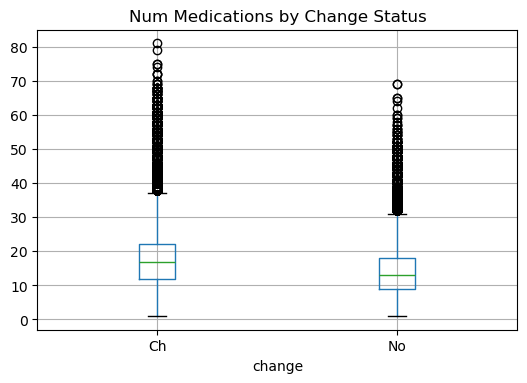

In [55]:
db.boxplot(column='num_medications', by='change', figsize=(6,4))
plt.title("Num Medications by Change Status")
plt.suptitle("")
plt.show()

#Examine the distribution of diagnoses categories

In [63]:
db['number_diagnoses'].value_counts().sort_index()

number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
Name: count, dtype: int64

In [64]:
db['number_diagnoses'].describe()

count    101766.000000
mean          7.422607
std           1.933600
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64

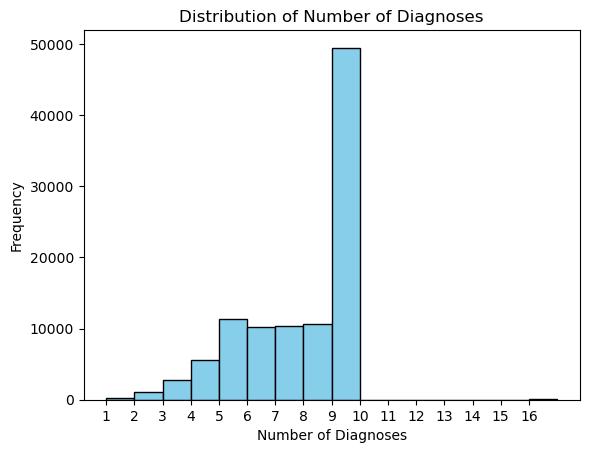

In [66]:
plt.hist(db['number_diagnoses'], bins= range(1,18), edgecolor='black',color='skyblue')
plt.xlabel("Number of Diagnoses")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Diagnoses")
plt.xticks(range(1, 17))
plt.show()

#Explore the distribution of patients across admission types, sources, and discharge dispositions.

In [67]:
db['admission_type_id'].value_counts().sort_index()

admission_type_id
1    53990
2    18480
3    18869
4       10
5     4785
6     5291
7       21
8      320
Name: count, dtype: int64

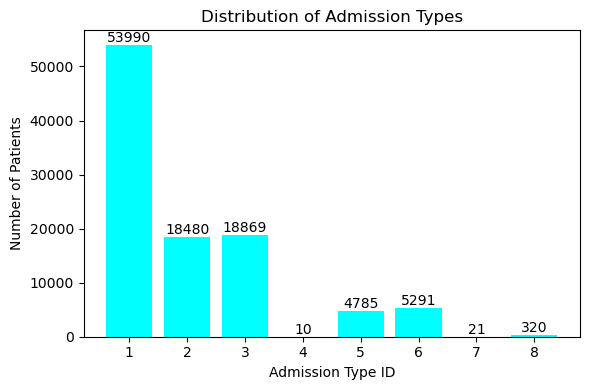

In [74]:
plt.figure(figsize=(6,4))
counts = db['admission_type_id'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='cyan')
plt.bar_label(bars)
plt.xlabel("Admission Type ID")
plt.ylabel("Number of Patients")
plt.title("Distribution of Admission Types")
plt.tight_layout()
plt.show()

In [68]:
db['discharge_disposition_id'].value_counts().sort_index()

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

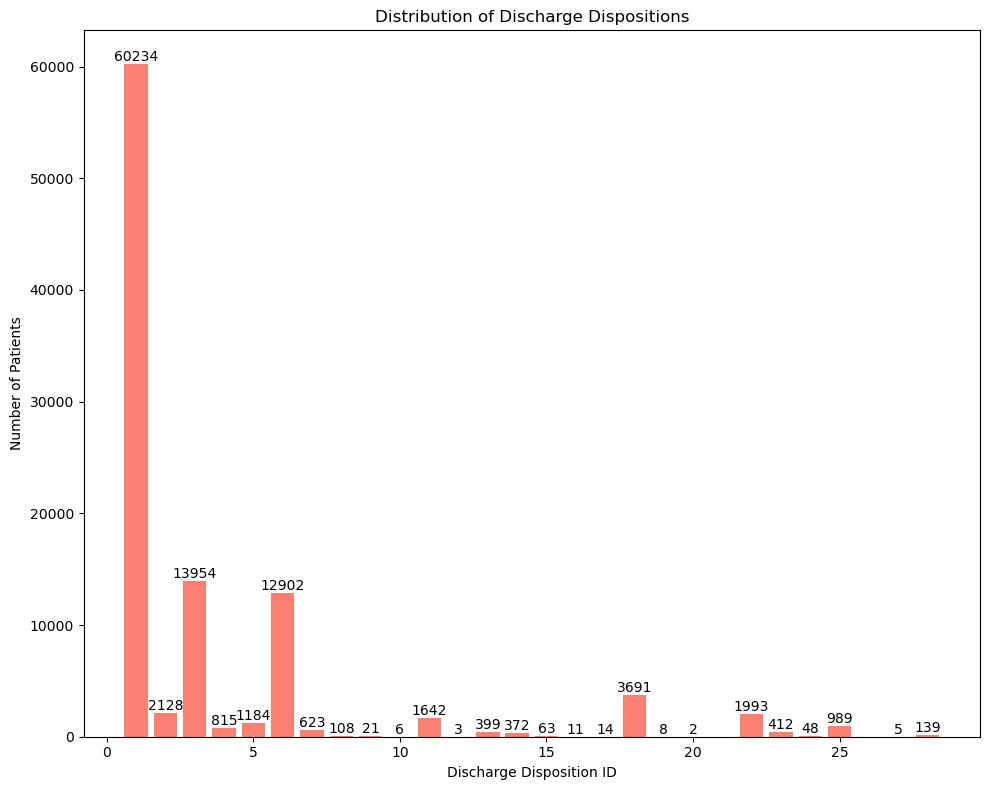

In [77]:
plt.figure(figsize=(10,8))
counts = db['discharge_disposition_id'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='salmon')
plt.bar_label(bars)
plt.xlabel("Discharge Disposition ID")
plt.ylabel("Number of Patients")
plt.title("Distribution of Discharge Dispositions")
plt.tight_layout()
plt.show()

In [69]:
db['admission_source_id'].value_counts().sort_index()

admission_source_id
1     29565
2      1104
3       187
4      3187
5       855
6      2264
7     57494
8        16
9       125
10        8
11        2
13        1
14        2
17     6781
20      161
22       12
25        2
Name: count, dtype: int64

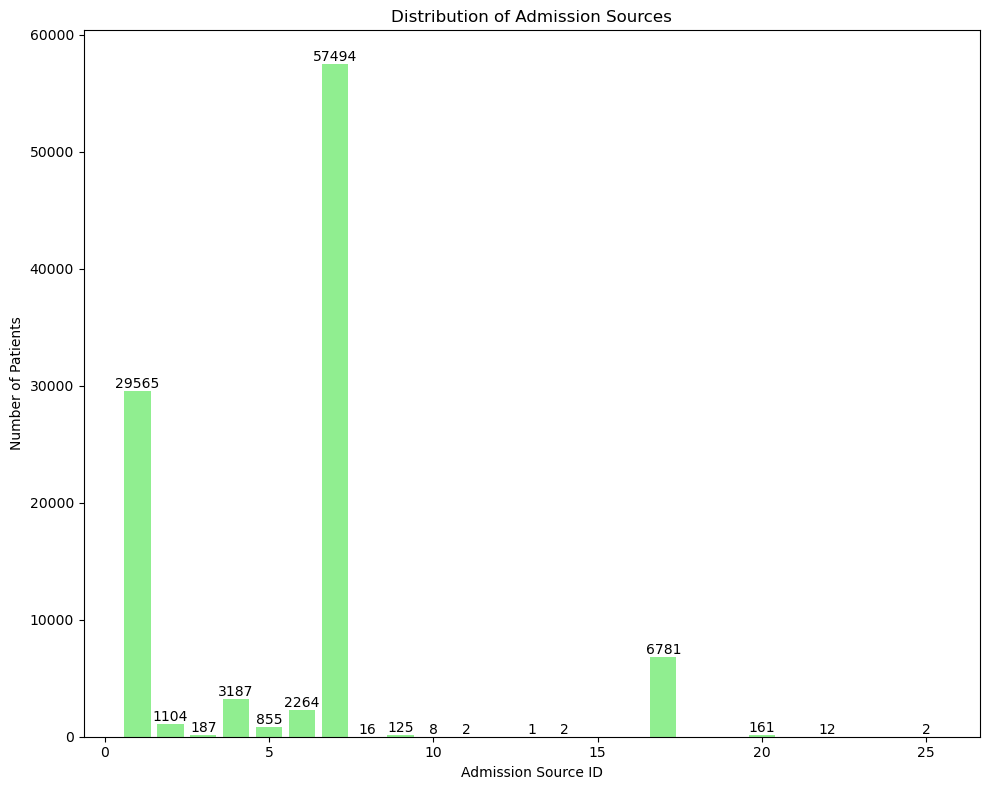

In [76]:
plt.figure(figsize=(10,8))
counts = db['admission_source_id'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='lightgreen')
plt.bar_label(bars)
plt.xlabel("Admission Source ID")
plt.ylabel("Number of Patients")
plt.title("Distribution of Admission Sources")
plt.tight_layout()
plt.show()

#Identify and visualize any outliers in the dataset, especially in numerical features

In [ ]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures","num_medications", "number_outpatient",
                "number_emergency","number_inpatient","number_diagnoses"]

In [ ]:
num_db = db[numeric_cols]

In [79]:
def find_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return col[(col < lower) | (col > upper)]

In [80]:
for col in numeric_cols:
    outliers = find_outliers(num_db[col])
    print(f"{col}: {len(outliers)} outliers")

time_in_hospital: 2252 outliers
num_lab_procedures: 143 outliers
num_procedures: 4954 outliers
num_medications: 2557 outliers
number_outpatient: 16739 outliers
number_emergency: 11383 outliers
number_inpatient: 7049 outliers
number_diagnoses: 281 outliers
